## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

## 2. Load Data

In [2]:
df = pd.read_csv("../data/BrentOilPrices.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_1044\907172931.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


## 3. Exploratory Data Analysis

### Plot Brent Prices

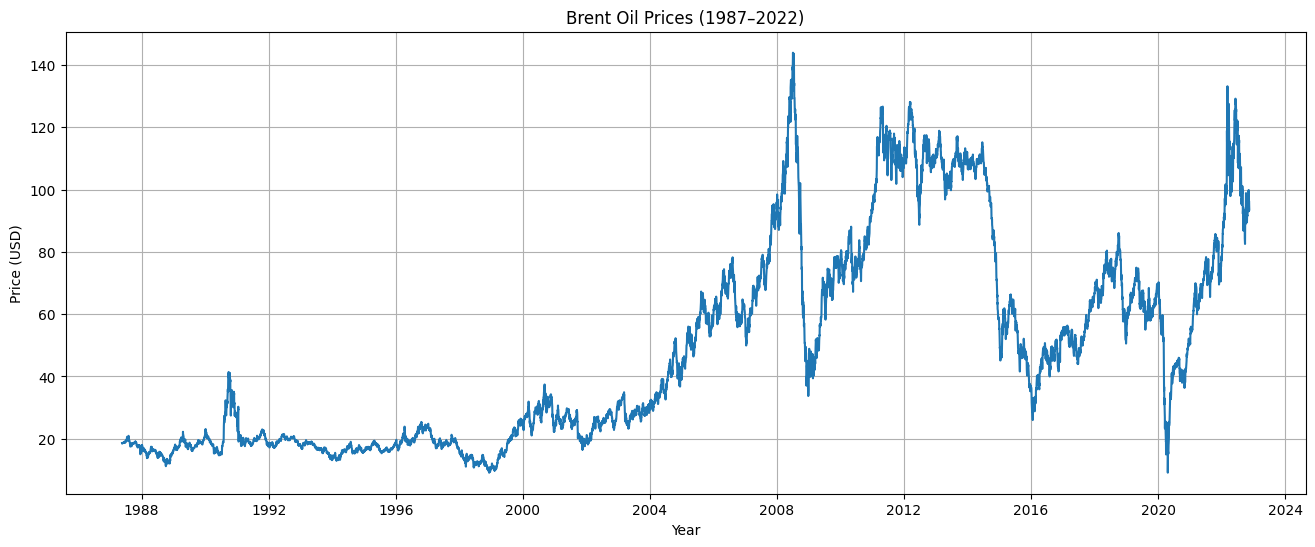

In [3]:
plt.figure(figsize=(16,6))
plt.plot(df["Date"], df["Price"])
plt.title("Brent Oil Prices (1987–2022)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

### Calculate Log Returns

In [4]:
df["Log_Return"] = np.log(df["Price"]).diff()

df = df.dropna()

### Plot Log Returns

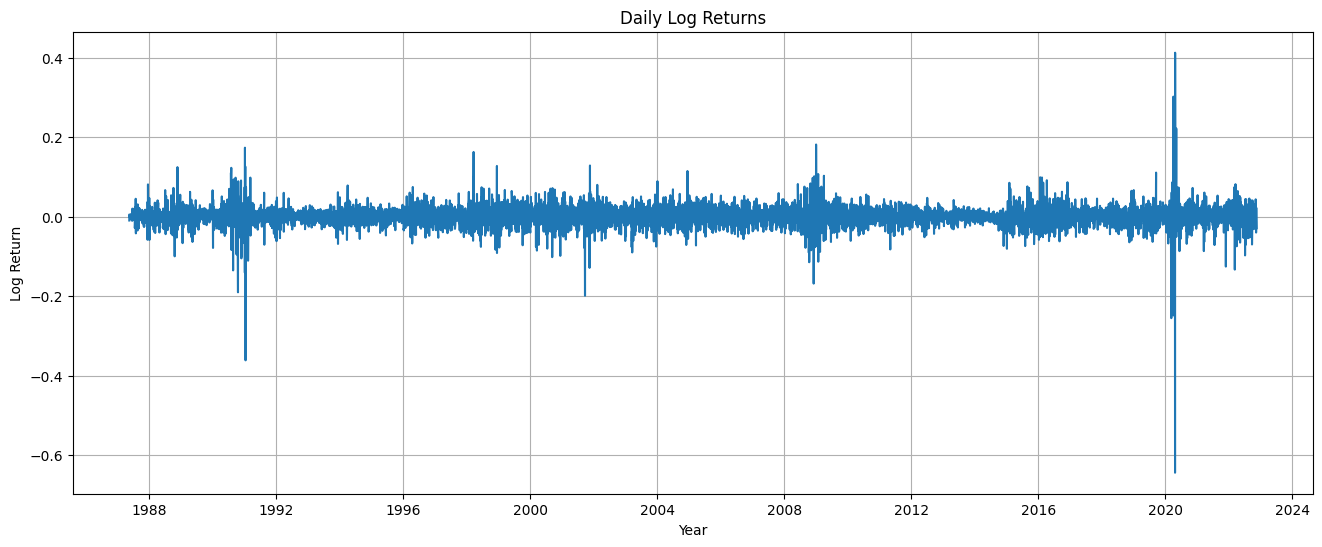

In [5]:
plt.figure(figsize=(16,6))
plt.plot(df["Date"], df["Log_Return"])
plt.title("Daily Log Returns")
plt.xlabel("Year")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

## 4. Bayesian Change Point Model

In [6]:
returns = df["Log_Return"].values

n = len(returns)

time = np.arange(n)

### Build the Model

In [7]:
with pm.Model() as model:

    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n-1
    )

    mu1 = pm.Normal(
        "mu1",
        mu=0,
        sigma=1
    )

    mu2 = pm.Normal(
        "mu2",
        mu=0,
        sigma=1
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )

    mu = pm.math.switch(
        time < tau,
        mu1,
        mu2
    )

    likelihood = pm.Normal(
        "likelihood",
        mu=mu,
        sigma=sigma,
        observed=returns
    )

    trace = pm.sample(
        draws=3000,
        tune=1000,
        target_accept=0.95,
        return_inferencedata=True
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 79 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## 5. Convergence Diagnostics

In [8]:
az.summary(trace)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,5e+03,3e+03,210,8900,269,502,1.01,190,73
mu1,5e-05,0.0017,-0.00096,0.00094,2415,1368,1.00,4.8e-05,0.00036
mu2,0.0003,0.003,-0.00099,0.0031,92,47,1.03,0.00031,0.0021
sigma,0.025532,0.00019,0.025,0.026,6279,6194,1.00,2.4e-06,1.7e-06


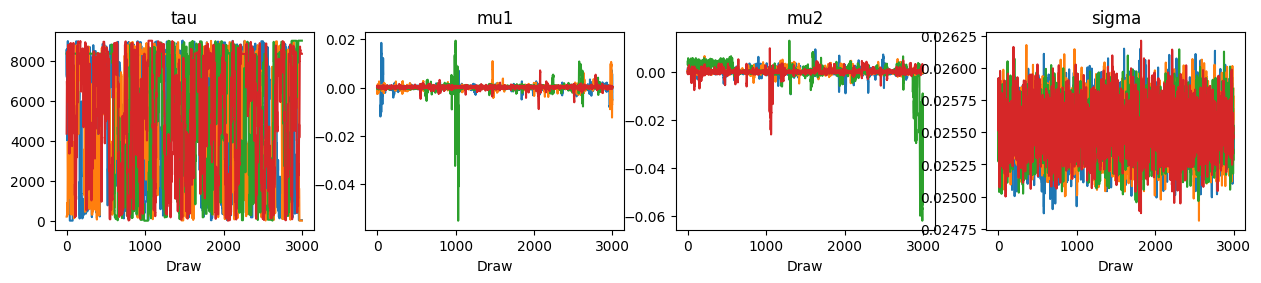

In [9]:
az.plot_trace(trace)
plt.show()

## 6. Posterior Distribution of Change Point

In [10]:
az.plot_posterior(
    trace,
    var_names=["tau"]
)

plt.show()

AttributeError: module 'arviz' has no attribute 'plot_posterior'

In [ ]:
tau_samples = trace.posterior["tau"].values.flatten()

estimated_tau = int(np.mean(tau_samples))

estimated_date = df.iloc[estimated_tau]["Date"]

print(estimated_date)

## 7. Posterior Distributions

In [ ]:
az.plot_posterior(
    trace,
    var_names=["mu1","mu2","sigma"]
)

plt.show()

## 8. Visualize Detected Change Point

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], returns)

plt.axvline(
    estimated_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Detected Change Point"
)

plt.legend()

plt.title("Detected Bayesian Change Point")

plt.show()